# Experiment 1 (v2) — Muon vs AdamW on FineWeb, HF models

From-scratch pretraining optimizer comparison, now with **HuggingFace models** (compact) and
**FineWeb** streaming data (no more overfitting — FineWeb is effectively unlimited).

Each model is **randomly initialized from its config** (`from_config`, not `from_pretrained`) and
trained for 5000 steps twice: **AdamW** (`torch.optim.AdamW`) vs the reference **Muon**. We compare
the two *within each model*.

### Before you run 
- **Gemma is gated.** Run `huggingface-cli login` (or set `HF_TOKEN`) and accept the license on the
  model page first, or it will be skipped. Its **256k vocab** needs a **smaller batch** (logits are huge).
- **LFM** needs `trust_remote_code=True` (already set).
- **Different tokenizers ⇒ loss is only comparable Adam-vs-Muon WITHIN a model**, never across models.

In [ ]:
# --- Setup -------------------------------------------------------------------
import importlib, subprocess, sys
for pkg in ("datasets", "transformers", "accelerate"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", pkg], check=True)

import math, time
from contextlib import nullcontext
import torch, torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
def amp():
    return torch.autocast("cuda", dtype=torch.bfloat16) if use_bf16 else nullcontext()

print("torch", torch.__version__, "| device:", device, "| bf16:", use_bf16,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Optional: log in for gated models (Gemma). Uncomment and paste a token, or run
# `huggingface-cli login` in a terminal beforehand.
from huggingface_hub import login
login("hf_...")


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


torch 2.4.1+cu124 | device: cuda | bf16: True | NVIDIA RTX 4000 Ada Generation


In [2]:
# --- Config (EDIT repo ids / batch sizes here) -------------------------------
MODELS = {
    "gpt2-medium": dict(repo="openai-community/gpt2-medium",         trust_remote_code=False, batch_size=16),
    "gemma3-370m": dict(repo="google/gemma-3-270m", trust_remote_code=False, batch_size=8),
    "lfm2.5-350m": dict(repo="LiquidAI/LFM2.5-350M",  trust_remote_code=True,  batch_size=16),
}

CFG = dict(
    steps          = 5000,
    block_size     = 256,
    adam_lr        = 3e-4,
    muon_lr        = 0.02,
    weight_decay   = 0.1,
    warmup         = 150,
    min_lr_frac    = 0.1,
    grad_clip      = 1.0,
    eval_every     = 100,
    eval_iters     = 50,
    log_every      = 50,
    seed           = 1337,
    # n_train_tokens = 25_000_000,   # ~enough for 5000 steps without heavy repetition
    # n_val_tokens   = 1_000_000,
    # fineweb_name   = "sample-10BT",
)
CFG

{'steps': 5000,
 'block_size': 256,
 'adam_lr': 0.0003,
 'muon_lr': 0.02,
 'weight_decay': 0.1,
 'warmup': 150,
 'min_lr_frac': 0.1,
 'grad_clip': 1.0,
 'eval_every': 100,
 'eval_iters': 50,
 'log_every': 50,
 'seed': 1337}

## Reference Muon (single-device)

Standard Muon (Keller Jordan): Nesterov momentum -> quintic Newton-Schulz orthogonalization
(singular values -> 1) -> aspect-ratio-scaled step. Applied to **2D hidden weight matrices** only;
embeddings, the (tied) LM head, norms and biases go to AdamW. Param classification below is generic,
so it works on any HF architecture.

In [3]:
# --- Reference Muon ----------------------------------------------------------
def zeropower_via_newtonschulz5(G, steps=5):
    assert G.ndim == 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.float()
    transposed = X.size(0) > X.size(1)
    if transposed:
        X = X.T
    X = X / (X.norm() + 1e-7)
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * (A @ A)
        X = a * X + B @ X
    if transposed:
        X = X.T
    return X

class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, weight_decay=0.0, ns_steps=5):
        super().__init__(params, dict(lr=lr, momentum=momentum,
                                      weight_decay=weight_decay, ns_steps=ns_steps))
    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, mom = group["lr"], group["momentum"]
            wd, ns  = group["weight_decay"], group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                st = self.state[p]
                if "m" not in st:
                    st["m"] = torch.zeros_like(g)
                buf = st["m"]
                buf.mul_(mom).add_(g)
                g = g.add(buf, alpha=mom)
                u = zeropower_via_newtonschulz5(g, ns)
                if wd:
                    p.mul_(1 - lr * wd)
                p.add_(u.to(p.dtype), alpha=-lr * max(1.0, p.size(0) / p.size(1)) ** 0.5)

print("Muon ready. NS self-check:")
_sv = torch.linalg.svdvals(zeropower_via_newtonschulz5(torch.randn(256, 128), 5))
print(f"  singular values min={_sv.min():.3f} max={_sv.max():.3f} (want ~1)")

Muon ready. NS self-check:
  singular values min=0.682 max=1.134 (want ~1)


In [4]:
# --- Data: WikiText-2 (small, fast) ------------------------------------------
from datasets import load_dataset

def build_data(tokenizer):
    ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
    def enc(split):
        ids = tokenizer("\n".join(ds[split]["text"]))["input_ids"]
        return torch.tensor(ids, dtype=torch.long)
    tr, va = enc("train"), enc("validation")
    print(f"  tokens: train={len(tr):,}  val={len(va):,}")
    return tr, va

build_fineweb = build_data   # alias so the existing run-all cell works unchanged

def get_batch(data, bs, bl):
    ix = torch.randint(len(data) - bl - 1, (bs,))
    x = torch.stack([data[i:i + bl] for i in ix])
    return x.to(device)

In [5]:
# --- Param split + optimizers + schedule + train -----------------------------
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

def classify_params(model):
    # Embeddings (and tied/untied LM head) -> AdamW; other 2D matrices -> Muon.
    embed_ids = set()
    for m in model.modules():
        if isinstance(m, nn.Embedding):
            embed_ids.add(id(m.weight))
    for name, m in model.named_modules():
        if name.endswith("lm_head") and getattr(m, "weight", None) is not None:
            embed_ids.add(id(m.weight))
    hidden, rest = [], []
    for _, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (hidden if (p.ndim == 2 and id(p) not in embed_ids) else rest).append(p)
    return hidden, rest

def build_optims(model, which):
    hidden, rest = classify_params(model)
    if which == "adamw":
        opts = [torch.optim.AdamW(hidden + rest, lr=CFG["adam_lr"],
                                  betas=(0.9, 0.95), weight_decay=CFG["weight_decay"])]
    else:
        opts = [Muon(hidden, lr=CFG["muon_lr"], momentum=0.95, weight_decay=CFG["weight_decay"]),
                torch.optim.AdamW(rest, lr=CFG["adam_lr"], betas=(0.9, 0.95),
                                  weight_decay=CFG["weight_decay"])]
    for o in opts:
        for g in o.param_groups:
            g["base_lr"] = g["lr"]
    n_h = sum(p.numel() for p in hidden)
    n_r = sum(p.numel() for p in rest)
    return opts, n_h, n_r

def lr_frac(step):
    if step < CFG["warmup"]:
        return step / max(1, CFG["warmup"])
    if step >= CFG["steps"]:
        return CFG["min_lr_frac"]
    prog = (step - CFG["warmup"]) / max(1, CFG["steps"] - CFG["warmup"])
    cos = 0.5 * (1 + math.cos(math.pi * prog))
    return CFG["min_lr_frac"] + (1 - CFG["min_lr_frac"]) * cos

@torch.no_grad()
def estimate_loss(model, data, bs):
    model.eval()
    tot = 0.0
    for _ in range(CFG["eval_iters"]):
        x = get_batch(data, bs, CFG["block_size"])
        with amp():
            tot += model(input_ids=x, labels=x).loss.item()
    model.train()
    return tot / CFG["eval_iters"]

def fresh_model(spec):
    # Seed right before init so AdamW and Muon runs start from identical random weights.
    trc = spec["trust_remote_code"]
    cfg = AutoConfig.from_pretrained(spec["repo"], trust_remote_code=trc)
    if hasattr(cfg, "use_cache"):
        cfg.use_cache = False
    torch.manual_seed(CFG["seed"])
    return AutoModelForCausalLM.from_config(cfg, trust_remote_code=trc).to(device)

def train_run(spec, which, train_data, val_data, bs):
    model = fresh_model(spec)
    opts, n_h, n_r = build_optims(model, which)
    print(f"    {which}: {n_h/1e6:.0f}M via Muon-path / {n_r/1e6:.0f}M via AdamW")
    model.train()
    log, t0 = [], time.time()
    for step in range(1, CFG["steps"] + 1):
        frac = lr_frac(step)
        for o in opts:
            for g in o.param_groups:
                g["lr"] = g["base_lr"] * frac
        x = get_batch(train_data, bs, CFG["block_size"])
        for o in opts:
            o.zero_grad(set_to_none=True)
        with amp():
            loss = model(input_ids=x, labels=x).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        for o in opts:
            o.step()
        if step % CFG["log_every"] == 0:
            log.append(dict(step=step, train_loss=loss.item(), val_loss=None,
                            sec=time.time() - t0))
        if step % CFG["eval_every"] == 0:
            vl = estimate_loss(model, val_data, bs)
            if log:
                log[-1]["val_loss"] = vl
            print(f"      step {step:5d}  train {loss.item():.3f}  val {vl:.3f}  "
                  f"ppl {math.exp(min(vl,20)):.1f}  {time.time()-t0:.0f}s")
    del model
    if device == "cuda":
        torch.cuda.empty_cache()
    return log

In [6]:
# --- Run all models ----------------------------------------------------------
results = {}
for name, spec in MODELS.items():
    print(f"\n{'='*64}\n{name}  ({spec['repo']})\n{'='*64}")
    try:
        tok = AutoTokenizer.from_pretrained(spec["repo"],
                                            trust_remote_code=spec["trust_remote_code"])
        if tok.pad_token is None and tok.eos_token is not None:
            tok.pad_token = tok.eos_token
        train_data, val_data = build_fineweb(tok)
        results[name] = {}
        for which in ["adamw", "muon"]:
            print(f"  --- {which.upper()} ---")
            results[name][which] = train_run(spec, which, train_data, val_data,
                                             spec["batch_size"])
        del train_data, val_data
    except Exception as e:
        print(f"  SKIPPED {name}: {type(e).__name__}: {e}")
print("\ndone.")


gpt2-medium  (openai-community/gpt2-medium)


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.73M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

  tokens: train=2,513,827  val=261,820
  --- ADAMW ---
    adamw: 287M via Muon-path / 67M via AdamW
      step   100  train 6.265  val 6.466  ppl 643.0  35s
      step   200  train 5.580  val 6.029  ppl 415.2  69s
      step   300  train 5.419  val 5.806  ppl 332.4  104s
      step   400  train 5.065  val 5.651  ppl 284.6  139s
      step   500  train 4.924  val 5.512  ppl 247.6  173s
      step   600  train 4.731  val 5.449  ppl 232.6  208s
      step   700  train 4.477  val 5.335  ppl 207.6  243s
      step   800  train 4.506  val 5.340  ppl 208.5  277s
      step   900  train 4.255  val 5.259  ppl 192.2  312s
      step  1000  train 4.156  val 5.237  ppl 188.2  347s
      step  1100  train 4.240  val 5.250  ppl 190.6  382s
      step  1200  train 4.115  val 5.189  ppl 179.3  416s
      step  1300  train 3.784  val 5.228  ppl 186.5  451s
      step  1400  train 3.854  val 5.177  ppl 177.1  486s
      step  1500  train 3.507  val 5.195  ppl 180.3  520s
      step  1600  train 3.501  

In [7]:
!pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


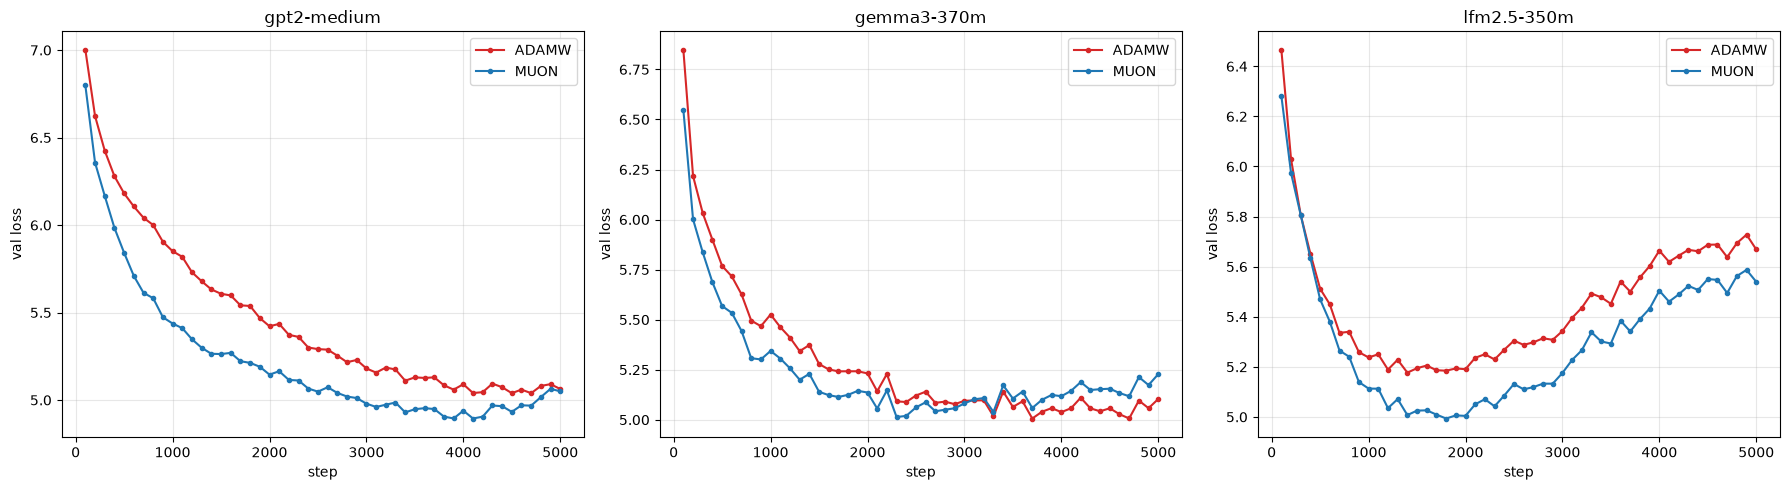

model         opt     best val  best ppl    final  wall(s)
gpt2-medium   adamw      5.039     154.4    5.063     3321
gpt2-medium   muon       4.894     133.5    5.050     4547
gemma3-370m   adamw      5.006     149.3    5.104     1332
gemma3-370m   muon       5.014     150.4    5.228     1714
lfm2.5-350m   adamw      5.177     177.1    5.669     1729
lfm2.5-350m   muon       4.994     147.5    5.539     3084


In [8]:
# --- Plot + summary ----------------------------------------------------------
import matplotlib.pyplot as plt

models = [m for m in results if results.get(m)]
if models:
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), squeeze=False)
    for ax, name in zip(axes[0], models):
        for which, col in [("adamw", "tab:red"), ("muon", "tab:blue")]:
            log = results[name].get(which, [])
            xs = [e["step"] for e in log if e.get("val_loss") is not None]
            ys = [e["val_loss"] for e in log if e.get("val_loss") is not None]
            if xs:
                ax.plot(xs, ys, "-o", ms=3, color=col, label=which.upper())
        ax.set_title(name); ax.set_xlabel("step"); ax.set_ylabel("val loss")
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

# Report BEST val (not final) — FineWeb shouldn't overfit, but best-val is the fair metric.
print(f"{'model':14}{'opt':6}{'best val':>10}{'best ppl':>10}{'final':>9}{'wall(s)':>9}")
for name in models:
    for which in ["adamw", "muon"]:
        log = results[name].get(which, [])
        vals = [e["val_loss"] for e in log if e.get("val_loss") is not None]
        if vals:
            b, f = min(vals), vals[-1]
            print(f"{name:14}{which:6}{b:>10.3f}{math.exp(min(b,20)):>10.1f}"
                  f"{f:>9.3f}{log[-1]['sec']:>9.0f}")

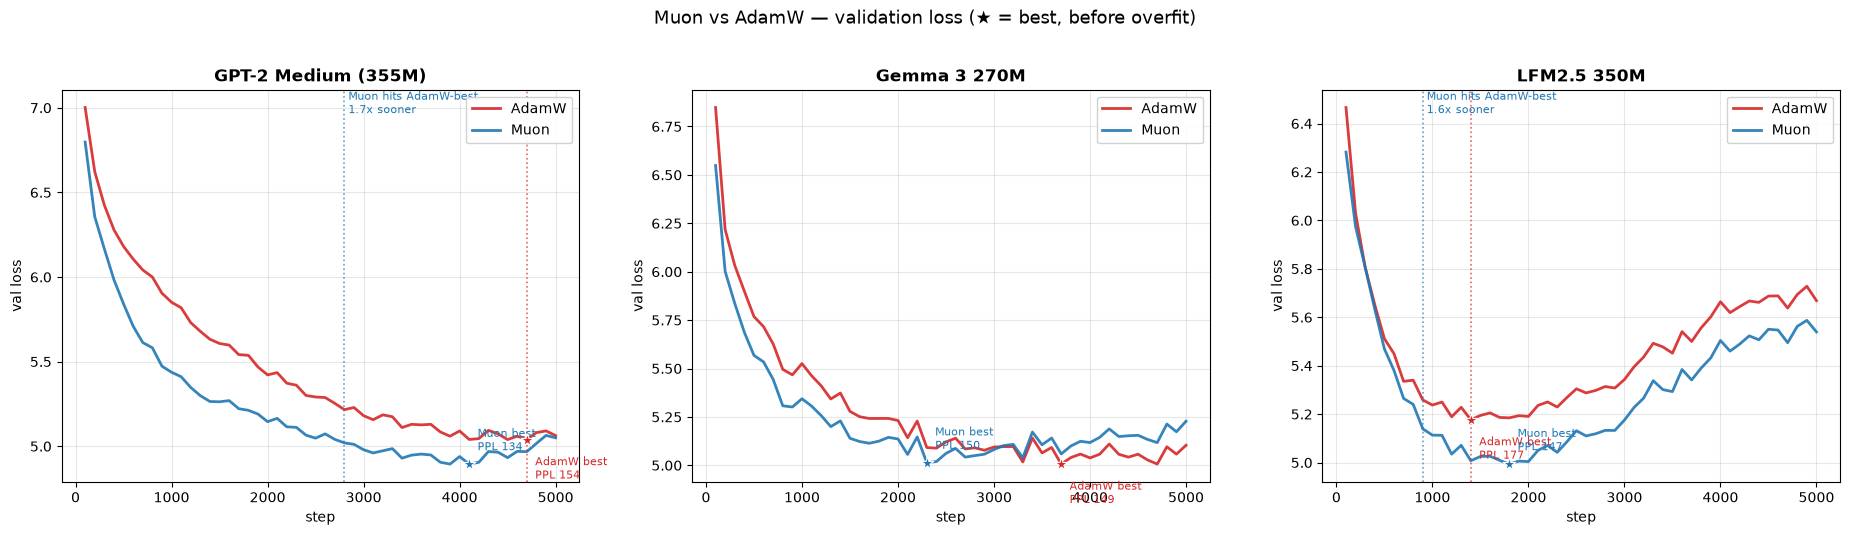

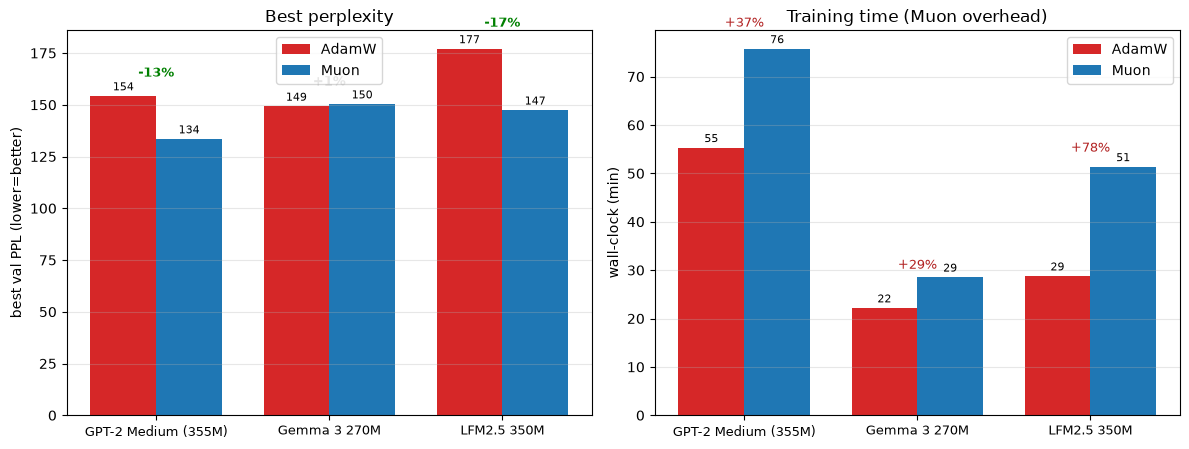


| model | optimizer | best val | best PPL | final val | wall (min) |
|---|---|---|---|---|---|
| GPT-2 Medium (355M) | AdamW | 5.039 | 154 | 5.063 | 55.3 |
| GPT-2 Medium (355M) | Muon | 4.894 | 134 | 5.050 | 75.8 |
| Gemma 3 270M | AdamW | 5.006 | 149 | 5.104 | 22.2 |
| Gemma 3 270M | Muon | 5.014 | 150 | 5.228 | 28.6 |
| LFM2.5 350M | AdamW | 5.177 | 177 | 5.669 | 28.8 |
| LFM2.5 350M | Muon | 4.994 | 147 | 5.539 | 51.4 |

saved: muon_val_curves.png, muon_summary_bars.png, results.json


In [9]:
# --- Better plots + summary (paste over the plot cell) ------------------------
import json, math
import matplotlib.pyplot as plt

# Pretty, corrected display names (Gemma is the 270M model).
DISPLAY = {
    "gpt2-medium": "GPT-2 Medium (355M)",
    "gemma3-370m": "Gemma 3 270M",
    "gemma3-270m": "Gemma 3 270M",
    "lfm2.5-350m": "LFM2.5 350M",
}
COL = {"adamw": "#d62728", "muon": "#1f77b4"}      # red / blue
LBL = {"adamw": "AdamW", "muon": "Muon"}

def series(log):
    xs = [e["step"] for e in log if e.get("val_loss") is not None]
    ys = [e["val_loss"] for e in log if e.get("val_loss") is not None]
    return xs, ys

def best_of(log):
    xs, ys = series(log)
    if not ys:
        return None
    i = min(range(len(ys)), key=lambda k: ys[k])
    return dict(step=xs[i], val=ys[i], ppl=math.exp(min(ys[i], 20)))

models = [m for m in results if results.get(m)]

# ---------- Figure 1: val-loss curves, best-val starred ----------------------
fig, axes = plt.subplots(1, len(models), figsize=(6.2 * len(models), 5.2), squeeze=False)
for ax, name in zip(axes[0], models):
    arms, bests = results[name], {}
    for which in ("adamw", "muon"):
        log = arms.get(which, [])
        xs, ys = series(log)
        if not xs:
            continue
        ax.plot(xs, ys, "-", lw=2, color=COL[which], alpha=0.9, label=LBL[which])
        b = best_of(log); bests[which] = b
        ax.scatter([b["step"]], [b["val"]], color=COL[which], s=90, marker="*",
                   zorder=5, edgecolor="white", linewidth=0.8)
        ax.annotate(f"{LBL[which]} best\nPPL {b['ppl']:.0f}", (b["step"], b["val"]),
                    textcoords="offset points",
                    xytext=(6, -28 if which == "adamw" else 10), fontsize=8, color=COL[which])
    if "adamw" in bests and "muon" in bests:
        a_best = bests["adamw"]["val"]
        mx, my = series(arms["muon"])
        hit = next((s for s, v in zip(mx, my) if v <= a_best), None)
        if hit:
            ax.axvline(hit, color=COL["muon"], ls=":", lw=1.2, alpha=0.7)
            ax.axvline(bests["adamw"]["step"], color=COL["adamw"], ls=":", lw=1.2, alpha=0.7)
            ax.text(hit, ax.get_ylim()[1],
                    f" Muon hits AdamW-best\n {bests['adamw']['step']/hit:.1f}x sooner",
                    fontsize=8, va="top", color=COL["muon"])
    ax.set_title(DISPLAY.get(name, name), fontsize=12, fontweight="bold")
    ax.set_xlabel("step"); ax.set_ylabel("val loss")
    ax.grid(alpha=0.3); ax.legend(loc="upper right", framealpha=0.9)
fig.suptitle("Muon vs AdamW — validation loss (★ = best, before overfit)", fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig("muon_val_curves.png", dpi=150, bbox_inches="tight")

# ---------- Figure 2: best-PPL + wall-clock bars -----------------------------
fig2, (axp, axw) = plt.subplots(1, 2, figsize=(12, 4.6))
labels = [DISPLAY.get(m, m) for m in models]; x = range(len(models)); w = 0.38
for j, which in enumerate(("adamw", "muon")):
    ppls = [(best_of(results[m].get(which, [])) or {"ppl": 0})["ppl"] for m in models]
    bars = axp.bar([i + (j - 0.5) * w for i in x], ppls, w, color=COL[which], label=LBL[which])
    axp.bar_label(bars, fmt="%.0f", fontsize=8, padding=2)
for i, m in enumerate(models):
    ba, bm = best_of(results[m].get("adamw", [])), best_of(results[m].get("muon", []))
    if ba and bm:
        d = (bm["ppl"] - ba["ppl"]) / ba["ppl"] * 100
        axp.text(i, max(ba["ppl"], bm["ppl"]) * 1.06, f"{d:+.0f}%", ha="center",
                 fontsize=9, color="green" if d < 0 else "gray", fontweight="bold")
axp.set_xticks(list(x)); axp.set_xticklabels(labels, fontsize=9)
axp.set_ylabel("best val PPL (lower=better)"); axp.set_title("Best perplexity")
axp.legend(); axp.grid(axis="y", alpha=0.3)
for j, which in enumerate(("adamw", "muon")):
    walls = [(results[m].get(which) or [{}])[-1].get("sec", 0) / 60 for m in models]
    bars = axw.bar([i + (j - 0.5) * w for i in x], walls, w, color=COL[which], label=LBL[which])
    axw.bar_label(bars, fmt="%.0f", fontsize=8, padding=2)
for i, m in enumerate(models):
    la, lm = results[m].get("adamw"), results[m].get("muon")
    if la and lm and la[-1].get("sec") and lm[-1].get("sec"):
        axw.text(i, max(la[-1]["sec"], lm[-1]["sec"]) / 60 * 1.06,
                 f"+{(lm[-1]['sec']/la[-1]['sec']-1)*100:.0f}%", ha="center",
                 fontsize=9, color="firebrick")
axw.set_xticks(list(x)); axw.set_xticklabels(labels, fontsize=9)
axw.set_ylabel("wall-clock (min)"); axw.set_title("Training time (Muon overhead)")
axw.legend(); axw.grid(axis="y", alpha=0.3)
fig2.tight_layout(); fig2.savefig("muon_summary_bars.png", dpi=150, bbox_inches="tight")
plt.show()

with open("results.json", "w") as f:
    json.dump(results, f)

print("\n| model | optimizer | best val | best PPL | final val | wall (min) |")
print("|---|---|---|---|---|---|")
for m in models:
    for which in ("adamw", "muon"):
        log = results[m].get(which, []); b = best_of(log)
        if b:
            fv = log[-1].get("val_loss"); fv = fv if fv is not None else float("nan")
            print(f"| {DISPLAY.get(m,m)} | {LBL[which]} | {b['val']:.3f} | {b['ppl']:.0f} "
                  f"| {fv:.3f} | {log[-1]['sec']/60:.1f} |")
print("\nsaved: muon_val_curves.png, muon_summary_bars.png, results.json")

## What to look for

- **Within each model, Adam vs Muon** — does Muon reach a lower val loss, and in how many fewer
  steps? (Earlier nano/small runs showed ~2x sample efficiency for Muon.)
- **Does the gap grow with scale / change by architecture?** GPT-2-medium vs Gemma vs LFM are
  different shapes and vocabs — Muon's edge may differ. Compare the *shape* of the curves, not
  absolute loss across models (different tokenizers).
- **Muon's wall-clock overhead** grows with model size (Newton-Schulz on bigger matrices). Check
  the wall(s) column; report per-step *and* per-second.
- **FineWeb should not overfit** at 5000 steps over ~25M unique tokens — if val keeps falling,
  consider more steps; if it turns up, raise `n_train_tokens`.
- Still single-seed, untuned LR. For the final post: sweep `muon_lr`/`adam_lr` and add 2 seeds.